In [2]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 2.7 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

# =========================
# LOAD DATA
# =========================

df = pd.read_csv(r"C:\Users\himan\Desktop\Projects\pathwayIQ\dataset\processed\cleaned_diabetic_data.csv")

X = df.drop(columns=["target"])
y = df["target"]

# =========================
# SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# =========================
# COLUMN TYPES
# =========================

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

# =========================
# PREPROCESSING
# =========================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# =========================
# SCALE POSITIVE CLASS
# =========================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

# =========================
# XGBOOST PIPELINE
# =========================

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

# =========================
# TRAIN
# =========================

xgb_pipeline.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


SHAP values shape: (20353, 190)


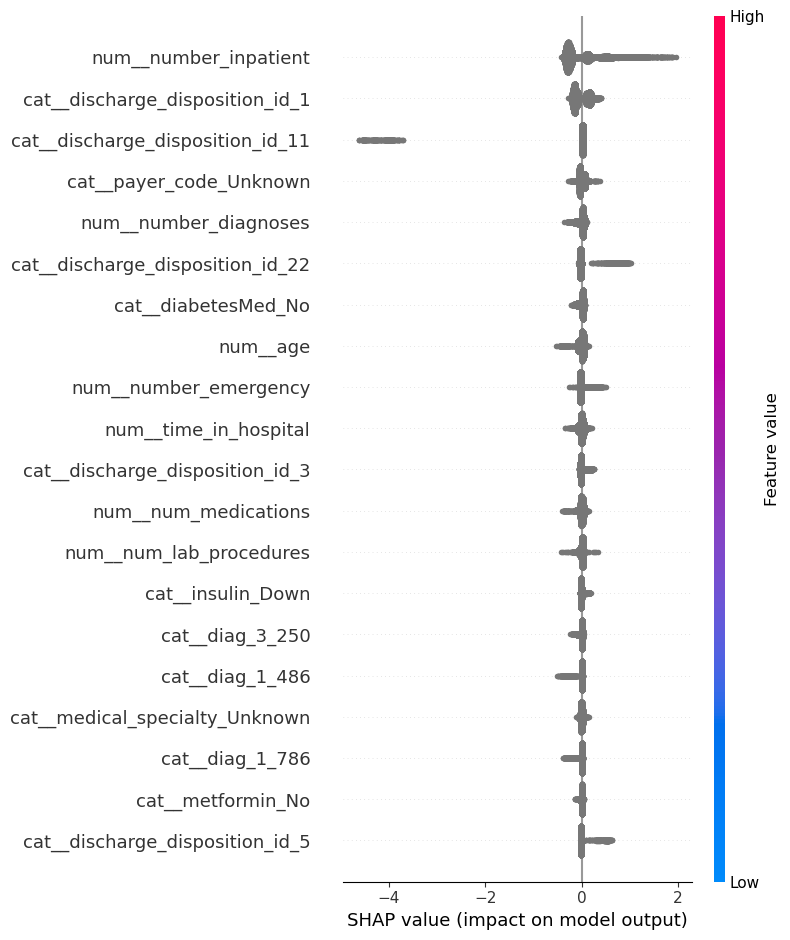

In [5]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

# =========================
# EXTRACT TRAINED XGBOOST MODEL
# =========================

xgb_model = xgb_pipeline.named_steps["classifier"]

# =========================
# TRANSFORM TEST DATA
# =========================

X_test_transformed = xgb_pipeline.named_steps[
    "preprocessor"
].transform(X_test)

# =========================
# GET FEATURE NAMES
# =========================

feature_names = xgb_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# =========================
# CREATE SHAP EXPLAINER
# =========================

explainer = shap.TreeExplainer(xgb_model)

# =========================
# COMPUTE SHAP VALUES
# =========================

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)

# =========================
# GLOBAL FEATURE IMPORTANCE
# =========================

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd

mean_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_shap
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
9,num__number_inpatient,0.294364
19,cat__discharge_disposition_id_1,0.145657
20,cat__discharge_disposition_id_11,0.087213
52,cat__payer_code_Unknown,0.054632
10,num__number_diagnoses,0.041387
25,cat__discharge_disposition_id_22,0.038888
188,cat__diabetesMed_No,0.038427
0,num__age,0.036246
8,num__number_emergency,0.035980
3,num__time_in_hospital,0.032383


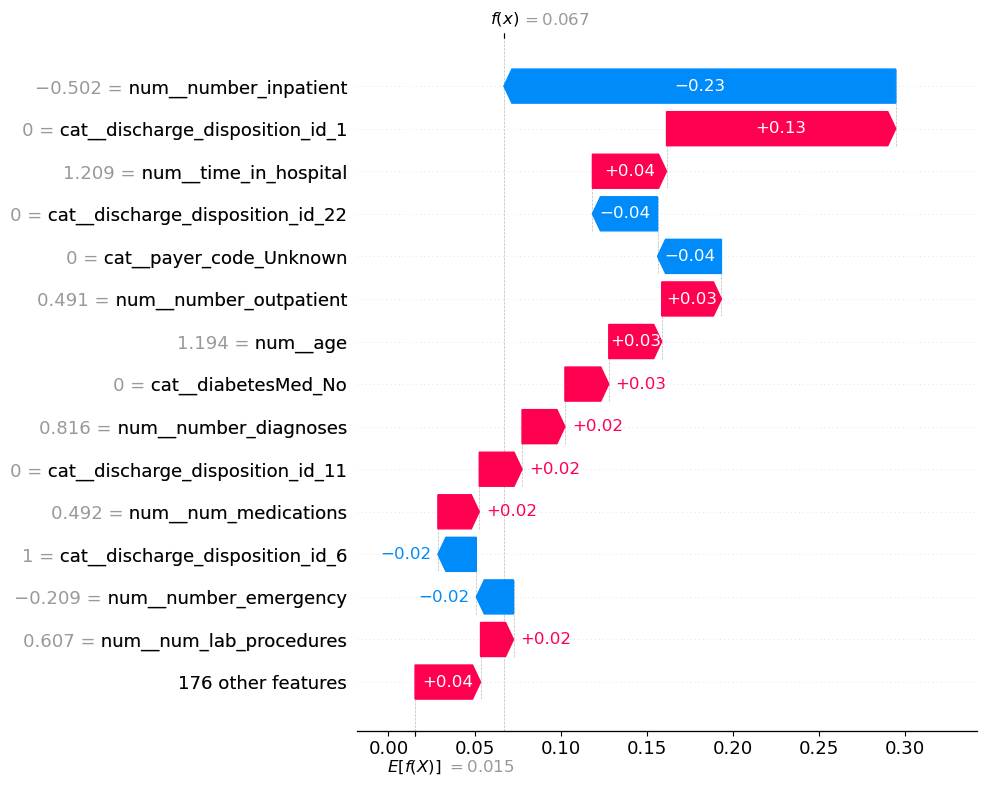

In [8]:
import numpy as np

# =========================
# SELECT PATIENT
# =========================

patient_idx = 25

# =========================
# CONVERT TO DENSE ROW
# =========================

patient_data = X_test_transformed[patient_idx].toarray().flatten()

# =========================
# CREATE EXPLANATION
# =========================

patient_explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=patient_data,
    feature_names=feature_names
)

# =========================
# WATERFALL PLOT
# =========================

shap.plots.waterfall(
    patient_explanation,
    max_display=15
)

In [11]:
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

In [12]:
import numpy as np

# Highest-risk patient
high_risk_idx = np.argmax(y_proba)
print("Highest predicted probability:", y_proba[high_risk_idx])

# Lowest-risk patient
low_risk_idx = np.argmin(y_proba)
print("Lowest predicted probability:", y_proba[low_risk_idx])

Highest predicted probability: 0.92123383
Lowest predicted probability: 0.0068822294


In [13]:
def plot_patient_explanation(patient_idx):
    
    patient_data = X_test_transformed[patient_idx].toarray().flatten()

    patient_explanation = shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,
        data=patient_data,
        feature_names=feature_names
    )

    shap.plots.waterfall(
        patient_explanation,
        max_display=15
    )

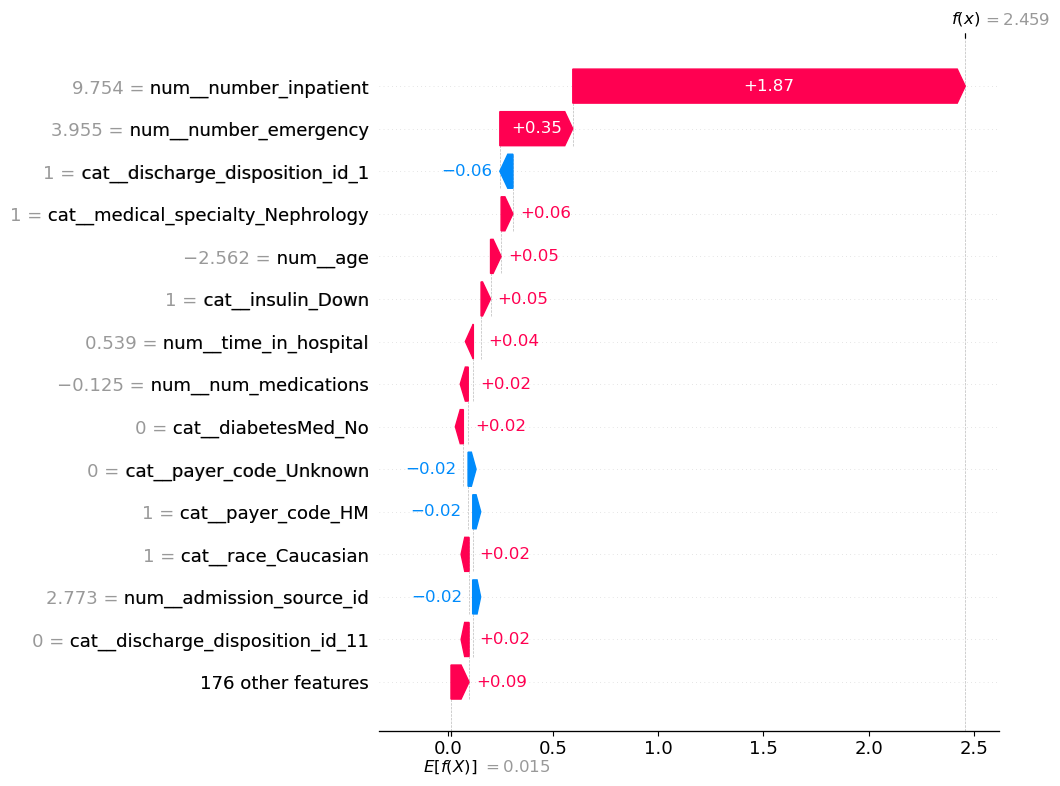

In [14]:
plot_patient_explanation(high_risk_idx)

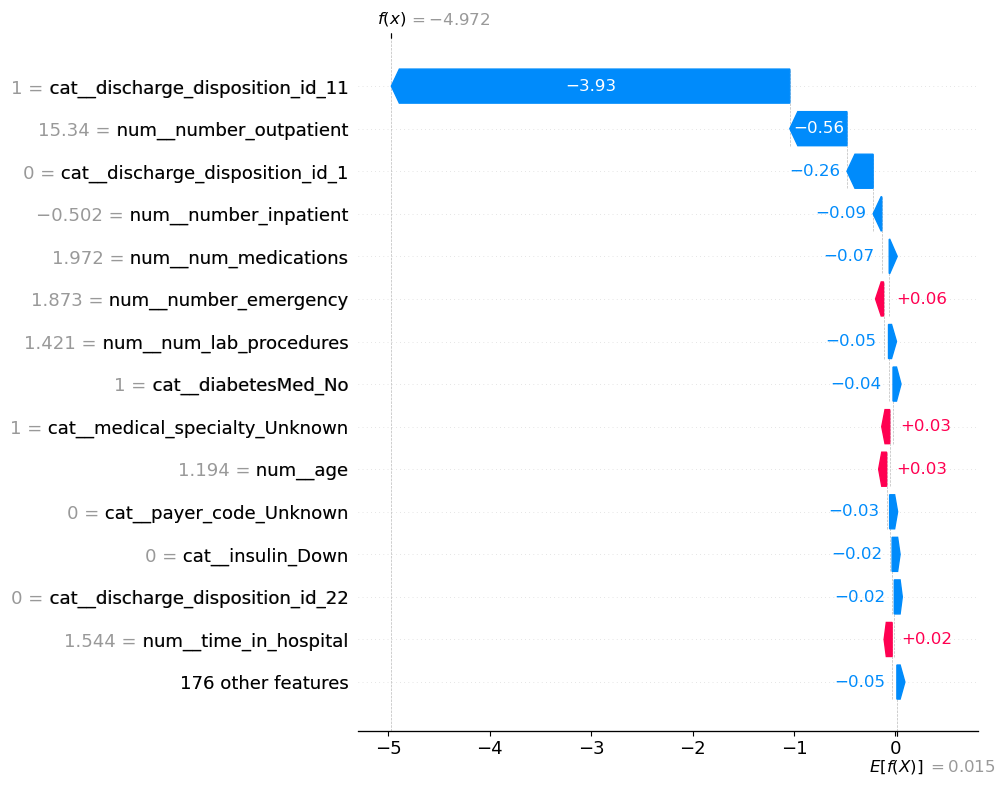

In [15]:
plot_patient_explanation(low_risk_idx)